# Human Activity Segmentation in Videos using Temporal Convolutional Networks (TCN)

**Course:** Pattern and Visual Recognition (CSAI3026P)  
**Institution:** University of Petroleum and Energy Studies, Dehradun  
**Supervisor:** Dr. Seetaram Maurya  
**Team:** Abhay Pawriya · Akshat Choudhary · Daksh Yadav · Lakshya Verma · Parul Padhee · Somya Pratap Singh · Sulabh Gupta

---
**Reference Paper:**  
C. Lea, M. D. Flynn, R. Vidal, A. Reiter, and G. D. Hager, *"Temporal Convolutional Networks for Action Segmentation and Detection"*, CVPR 2017, pp. 156–165.

**Dataset:** GTEA — https://ai.stanford.edu/~alireza/GTEA/



**Features source:** https://github.com/yabufarha/ms-tcn

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Setup and Extraction

The GTEA dataset is loaded from Google Drive. If not already extracted, the compressed file is unzipped and the directory structure is verified to ensure correct data access.

In [20]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/gtea.zip"
extract_path = "/content/drive/MyDrive/gtea"

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/drive/MyDrive/")
    print("Done ✅")
else:
    print("Already extracted ✅")

DATASET_DIR = extract_path

print(os.listdir(DATASET_DIR))

Already extracted ✅
['Videos', 'features', 'groundTruth', 'splits', 'mapping.txt']


## Label Mapping

Each activity label is mapped to a numerical index using the provided mapping file. This conversion is necessary for training the model using classification loss functions.

In [21]:
label_map = {}

with open(os.path.join(DATASET_DIR, "mapping.txt")) as f:
    for line in f:
        idx, label = line.strip().split()
        label_map[label] = int(idx)

num_classes = len(label_map)
print("Classes:", num_classes)

Classes: 11


## Custom Dataset Class

A custom PyTorch Dataset is implemented to load feature sequences and corresponding frame-wise labels. Data normalization is applied to improve model performance.

In [27]:
import torch
import numpy as np
from torch.utils.data import Dataset

class GTEADataset(Dataset):
    def __init__(self, data_dir):
        self.features_dir = os.path.join(data_dir, "features")
        self.labels_dir = os.path.join(data_dir, "groundTruth")
        self.files = os.listdir(self.features_dir)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]

        X = np.load(os.path.join(self.features_dir, file))
        X = (X - np.mean(X)) / (np.std(X) + 1e-8)

        label_file = file.replace(".npy", ".txt")
        with open(os.path.join(self.labels_dir, label_file)) as f:
            y = [label_map[line.strip()] for line in f.readlines()]

        return torch.tensor(X.T, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

## Data Splitting and Loading

The dataset is split into training and testing sets. DataLoader is used to efficiently handle batching and shuffling during training.

In [28]:
from torch.utils.data import DataLoader, random_split

dataset = GTEADataset(DATASET_DIR)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1)

print("Train:", len(train_data), "Test:", len(test_data))

Train: 22 Test: 6


## Temporal Convolutional Network (TCN)

A Temporal Convolutional Network is implemented to model sequential dependencies in video data. It uses 1D convolutions to capture temporal patterns across frames.

In [29]:
import torch.nn as nn

class TCN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(input_size, 128, 3, padding=1)
        self.conv2 = nn.Conv1d(128, 128, 3, padding=1)
        self.conv3 = nn.Conv1d(128, 128, 3, padding=1)

        self.relu = nn.ReLU()
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, time, features)

        x = x.transpose(1, 2)  # ✅ FIX HERE

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        x = x.transpose(1, 2)

        return self.fc(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TCN(2048, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model Ready ✅")

Model Ready ✅


In [30]:
X, y = next(iter(train_loader))
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1, 1384, 2048])
y shape: torch.Size([1, 1384])


## Model Training

The model is trained over multiple epochs using cross-entropy loss and the Adam optimizer. The objective is to minimize prediction error across time steps.

In [31]:
import matplotlib.pyplot as plt

losses = []

for epoch in range(5):
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)   # ✅ NO TRANSPOSE HERE

        outputs = outputs.view(-1, outputs.shape[-1])
        y = y.view(-1)

        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 39.2476
Epoch 2, Loss: 25.7832
Epoch 3, Loss: 20.2229
Epoch 4, Loss: 17.3069
Epoch 5, Loss: 14.8378


## Training Loss Visualization

The training loss is plotted across epochs to observe the learning behavior and convergence of the model.

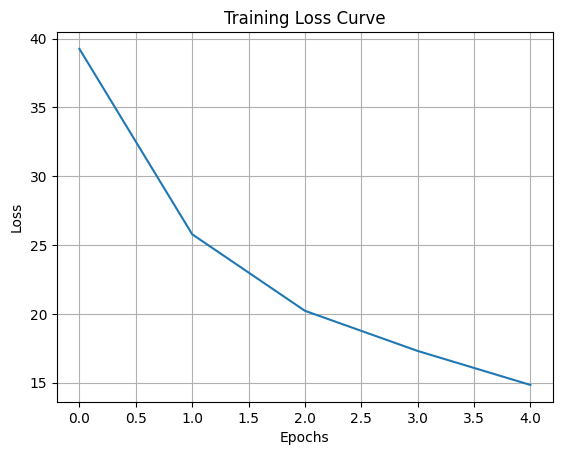

In [32]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

## Model Evaluation

The trained model is evaluated using Precision, Recall, and F1 Score to measure its performance on unseen data.

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)

        outputs = model(X)

        preds = torch.argmax(outputs, dim=-1).cpu().numpy().flatten()
        labels = y.numpy().flatten()

        all_preds.extend(preds)
        all_labels.extend(labels)

print("Precision:", precision_score(all_labels, all_preds, average='macro'))
print("Recall:", recall_score(all_labels, all_preds, average='macro'))
print("F1 Score:", f1_score(all_labels, all_preds, average='macro'))

Precision: 0.6491752100148641
Recall: 0.5928587547802431
F1 Score: 0.604397904557463


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix Analysis

A confusion matrix is generated to analyze class-wise prediction performance and identify patterns of misclassification.

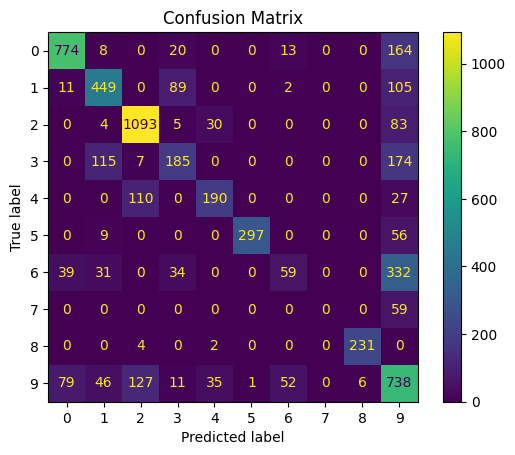

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Sample Predictions

A comparison of predicted labels and ground truth labels is displayed to qualitatively assess model performance.

In [35]:
print("Sample Predictions:", all_preds[:20])
print("Ground Truth:", all_labels[:20])

Sample Predictions: [np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(0), np.int64(0), np.int64(0)]
Ground Truth: [np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(0), np.int64(0), np.int64(0)]
